## Are the Recon Files Good Enough (monthly files) ##

Comparing the recon fields to v202111 fields.  Are the monthly averages of key quantities similar to the particular year, given the range of values across years?

In [1]:
import cmocean.cm as cm
import copy
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from salishsea_tools import viz_tools

In [167]:
endyear = 2025
nyears = endyear - 2007 + 1

In [2]:
bathy = xr.open_dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc')
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')

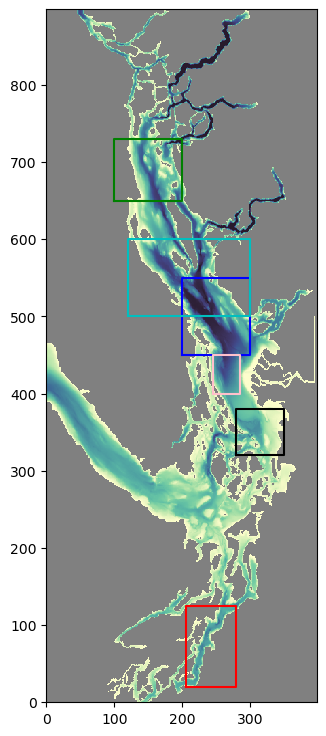

In [3]:
def plot_box(ax, corn, colour):
    ax.plot([corn[2], corn[3], corn[3], corn[2], corn[2]], 
            [corn[0], corn[0], corn[1], corn[1], corn[0]], '-', color=colour)
fig, ax = plt.subplots(1, 1, figsize=(5, 9))
mycmap = cm.deep
mycmap.set_bad('grey')
ax.pcolormesh(bathy['Bathymetry'], cmap=mycmap)
viz_tools.set_aspect(ax);
SoG_center = [450, 550, 200, 300]
plot_box(ax, SoG_center, 'b')
SoG_ncenter = [500, 600, 120, 300]
plot_box(ax, SoG_ncenter, 'c')
SoG_south = [320, 380, 280, 350]
plot_box(ax, SoG_south, 'k')
SoG_venus = [400, 450, 245, 285]
plot_box(ax, SoG_venus, 'pink')
SoG_north = [650, 730, 100, 200]
plot_box(ax, SoG_north, 'g')
PS_main = [20, 125, 205, 280]  # a bit smaller, to eliminate a piece of Hood Canal
plot_box(ax, PS_main, 'r') 


In [4]:
def triple_plot(it, days, v202111, v_3h, var, SoG_north, mesh, cmap, vmin, vmax, dv):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    v202111[var][it, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]].plot(ax=axs[0], cmap=cmap, vmin=vmin, vmax=vmax)
    v_3h[var][it+days*24, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]].plot(ax=axs[1], cmap=cmap, vmin=vmin, vmax=vmax)
    (v_3h[var][it+days*24, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]] 
     - v202111[var][it, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]]).plot(
    ax=axs[2], vmin=-dv, vmax=dv, cmap=cm.balance)
    print (np.ma.masked_array(v202111[var][it, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]],
                          mask=1-mesh.tmask[0, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]]).mean())
    print (np.ma.masked_array(v_3h[var][it+days*24, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]],
                          mask=1-mesh.tmask[0, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]]).mean())

In [5]:
def triple_plot_mean(v3h, recon, var, cmap, vmin, vmax, dv, nomask=False):
    mapA = copy.copy(cmap)
    mymap = mapA.with_extremes(bad='burlywood')
    fig, axs = plt.subplots(1, 3, figsize=(15, 9))
    v3hmean = v3h[var].mean(axis=0)
    reconmean = recon[var].mean(axis=0)
    if nomask:
        v3hmean.plot(ax=axs[0], cmap=mymap)
        reconmean.plot(ax=axs[1], cmap=mymap)
    else:
        v3hmean.where(v3hmean != 0).plot(ax=axs[0], cmap=mymap, vmin=vmin, vmax=vmax)
        reconmean.where(reconmean != 0).plot(ax=axs[1], cmap=mymap, vmin=vmin, vmax=vmax)
    (reconmean - v3hmean).where(reconmean - v3hmean != 0).plot(
    ax=axs[2], vmin=-dv, vmax=dv, cmap=cm.balance)
    return fig, axs

In [150]:
month_end_leap = {1: 31, 2: 29, 3:31, 4:30, 5:31, 6:30, 7:31, 8:31, 9:30, 10:31, 11:30, 12:31}
month_end =      {1: 31, 2: 28, 3:31, 4:30, 5:31, 6:30, 7:31, 8:31, 9:30, 10:31, 11:30, 12:31}

In [8]:
def calculate_mean(ds, mesh, box, idepth, var):
    if idepth[0] == idepth[1]:
        cut = ds[var][:, idepth[0], box[0]:box[1], box[2]:box[3]]
        tm = 1 - mesh.tmask[0, idepth[0], box[0]:box[1], box[2]:box[3]]
    else:
        cut = ds[var][:, idepth[0]:idepth[1], box[0]:box[1], box[2]:box[3]]
        tm = 1 - mesh.tmask[0, idepth[0]:idepth[1], box[0]:box[1], box[2]:box[3]]
    time_mean = cut.mean(axis=0)
    
    masked = np.ma.masked_array(time_mean, mask=tm)
    return masked.mean()

In [168]:
def calculate_timeseries(smonth, emonth, filestring, mesh, box, idepth, var):
    mean_temp_v = np.zeros((nyears, emonth-smonth))
    mean_temp_v_time = np.empty((nyears, emonth-smonth), dtype='datetime64[ns]')
    for iy, year in enumerate(range(2007, endyear+1, 1)):
        if year in [2008, 2012, 2016, 2020, 2024]:
            monthe = month_end_leap
        else:
            monthe = month_end
        for im, month in enumerate(range(smonth, emonth, 1)):
            last_day = monthe[month]
            mean_temp_v_time[iy, im] = dt.datetime(year, month, 1)
            ds = xr.open_dataset(filestring(year, month, last_day))
            mean_temp_v[iy, im] = calculate_mean(ds, mesh, box, idepth, var)
            ds.close()
    return mean_temp_v, mean_temp_v_time

In [10]:
def calculate_ts_newrun(smonth, emonth, syear, eyear, filestring, mesh, box, idepth, var):
    mean_temp_3h = np.zeros((eyear-syear, emonth-smonth))
    mean_temp_3h_time = np.empty((eyear-syear, emonth-smonth), dtype='datetime64[ns]')
    for iy, year in enumerate(range(syear, eyear, 1)):
        for im, month in enumerate(range(smonth, emonth, 1)):
            mean_temp_3h_time[iy, im] = dt.datetime(year, month, 1)
            ds = xr.open_dataset(filestring(year, month))
            mean_temp_3h[iy, im] = calculate_mean(ds, mesh, box, idepth, var)
            ds.close()
    return mean_temp_3h, mean_temp_3h_time

### Sea Surface Temperature in the CSoG ###

Not a good choice of metric?  This region is the plume region and we know it is highly stochastic.

In [169]:
# January - Dec
filestring_template = lambda year, month, last_day: f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_grid_T_{year}{month:02d}01_{year}{month:02d}{last_day:02d}.nc'
mean_tempC_v, mean_tempC_v_time = calculate_timeseries(1, 12+1, filestring_template, mesh, SoG_center, (0, 0), 'votemper')

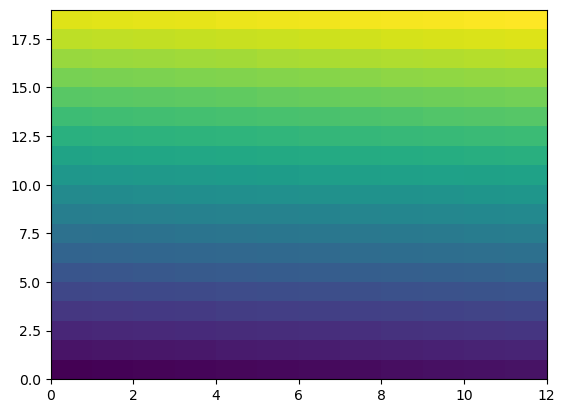

In [171]:
plt.pcolormesh(np.array(mean_tempC_v_time, dtype='datetime64[s]').astype('int64'));

In [172]:
np.savetxt('mean_tempC_v.csv', mean_tempC_v , comments=f'{dt.date.today}')
np.savetxt('mean_tempC_v_time.csv', mean_tempC_v_time , comments=f'{dt.date.today}')

In [194]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_tempC_3h, mean_tempC_3h_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, mesh, SoG_center, 
                                                        (0, 0), 'votemper')


In [273]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Pluck/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_tempC_pl, mean_tempC_pl_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, mesh, SoG_center, 
                                                        (0, 0), 'votemper')

In [278]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_tempC_3h_w1hS, mean_tempC_3h_w1hs_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                            mesh, SoG_center, (0, 0), 'votemper')


In [ ]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_tempC_recon, mean_tempC_recon_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, 
                                                              mesh, SoG_center, (0, 0), 'votemper')

In [280]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_tempC_recon_w1hS, mean_tempC_recon_w1hS_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                                  mesh, SoG_center, (0, 0), 'votemper')

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(15, 10))
axs[0].plot(mean_tempC_v_time.flatten(), mean_tempC_v.flatten(), label='v202111', marker='+', linestyle='--');

for iy, year in enumerate(range(2007, endyear+1, 1)):
    axs[0].plot(mean_tempC_v_time[iy], mean_tempC_v.mean(axis=0), label='v202111', linestyle=':', color='grey');
    axs[1].plot(mean_tempC_v_time[iy], mean_tempC_v[iy] - mean_tempC_v.mean(axis=0), label='v202111', marker='+', linestyle='--', color='tab:blue');
for iy, year in enumerate(range(2008, 2008+1, 1)):
    axs[0].plot(mean_tempC_3h_time[iy], mean_tempC_3h[iy], 'ro', label='gemlam every 3h')
    axs[1].plot(mean_tempC_3h_time[iy], mean_tempC_3h[iy] - mean_tempC_v.mean(axis=0) , 'ro', label='gemlam every 3h')
    axs[0].plot(mean_tempC_recon_time[iy], mean_tempC_recon[iy], 'bs', label='recon')
    axs[1].plot(mean_tempC_recon_time[iy], mean_tempC_recon[iy] - mean_tempC_v.mean(axis=0) , 'bs', label='recon')
for ax in axs:
    ax.set_xlabel('Year')
    ax.set_ylabel('Conservative Temperature ($^o$C)')
#    ax.legend()
    ax.grid();

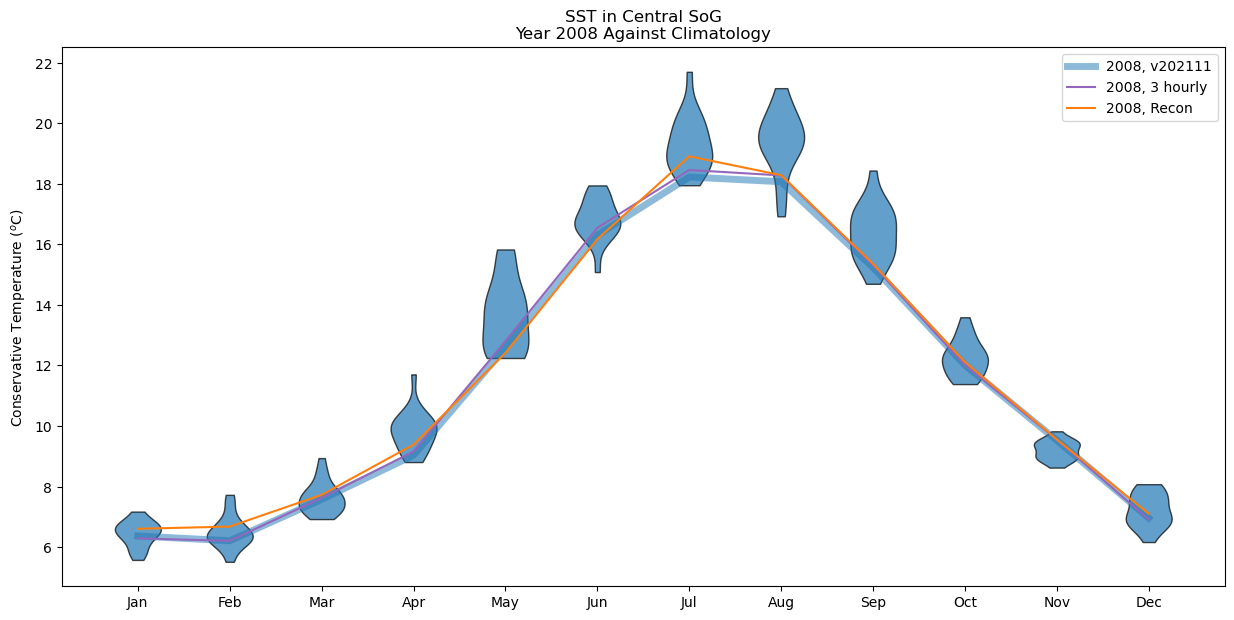

In [303]:
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
parts = ax.violinplot(mean_tempC_v, positions=range(1, 13), showmeans=False, showmedians=False, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_edgecolor('black')    # Border color
    pc.set_alpha(0.7)            # Transparency
iy, year = 1, 2008
ax.plot(range(1, 13), mean_tempC_v[1], 'tab:blue', alpha=0.5, linewidth=5, label='2008, v202111')
ax.plot(range(1, 13), mean_tempC_3h[0], 'tab:purple', label='2008, 3 hourly')
#ax.plot(range(1, 5), mean_tempC_pl[0], label='2008, 3 hourly Pluck')
#ax.plot(range(1, 5), mean_tempC_3h_w1hS[0], label='2008, 3h_w1hS')
ax.plot(range(1, 13), mean_tempC_recon[0], 'tab:orange', label='2008, Recon')
#ax.plot(range(1, 5), mean_tempC_recon_w1hS[0], label='2008, Recon_w1hS')


ax.set_title('SST in Central SoG\nYear 2008 Against Climatology')
ax.set_ylabel('Conservative Temperature ($^o$C)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend();
#ax.set_ylim(6, 20);

### Sea Surface Temperature in the Puget Main ###

In [204]:
# January - May
filestring_template = lambda year, month, last_day: f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_grid_T_{year}{month:02d}01_{year}{month:02d}{last_day:02d}.nc'
mean_temp_v, mean_temp_v_time = calculate_timeseries(1, 12+1, filestring_template, mesh, PS_main, (0, 0), 'votemper')
np.savetxt('mean_temp_v.csv', mean_temp_v , comments=f'{dt.date.today}')
np.savetxt('mean_temp_v_time.csv', mean_temp_v_time , comments=f'{dt.date.today}')

In [205]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_temp_3h, mean_temp_3h_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, mesh, 
                                                      PS_main, (0, 0), 'votemper')

In [285]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Pluck/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_temp_pl, mean_temp_pl_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, mesh, 
                                                      PS_main, (0, 0), 'votemper')

In [277]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_temp_3h_w1hS, mean_temp_3h_w1hs_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                            mesh, PS_main, (0, 0), 'votemper')

In [219]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_temp_recon, mean_temp_recon_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, 
                                                            mesh, PS_main, (0, 0), 'votemper')

In [281]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_temp_recon_w1hS, mean_temp_recon_w1hS_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                                  mesh, PS_main, (0, 0), 'votemper')

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(15, 10))
axs[0].plot(mean_temp_v_time.flatten(), mean_temp_v.flatten(), label='v202111', marker='+', linestyle='--');
for iy, year in enumerate(range(2007, endyear+1, 1)):
    axs[0].plot(mean_temp_v_time[iy], mean_temp_v.mean(axis=0), label='v202111', linestyle=':', color='grey');
    axs[1].plot(mean_temp_v_time[iy], mean_temp_v[iy] - mean_temp_v.mean(axis=0), label='v202111', marker='+', 
                linestyle='--', color='tab:blue');

for iy, year in enumerate(range(2008, 2008+1, 1)):
    axs[0].plot(mean_temp_3h_time[iy], mean_temp_3h[iy], 'ro', label='gemlam every 3h')
    axs[1].plot(mean_temp_3h_time[iy], mean_temp_3h[iy] - mean_temp_v.mean(axis=0) , 'ro', label='gemlam every 3h')
    axs[0].plot(mean_temp_recon_time[iy], mean_temp_recon[iy], 'bs', label='recon')
    axs[1].plot(mean_temp_recon_time[iy], mean_temp_recon[iy] - mean_temp_v.mean(axis=0) , 'bs', label='recon')
for ax in axs:
    ax.set_xlabel('Year')
    ax.set_ylabel('Conservative Temperature ($^o$C)')
#    ax.legend()
    ax.grid();

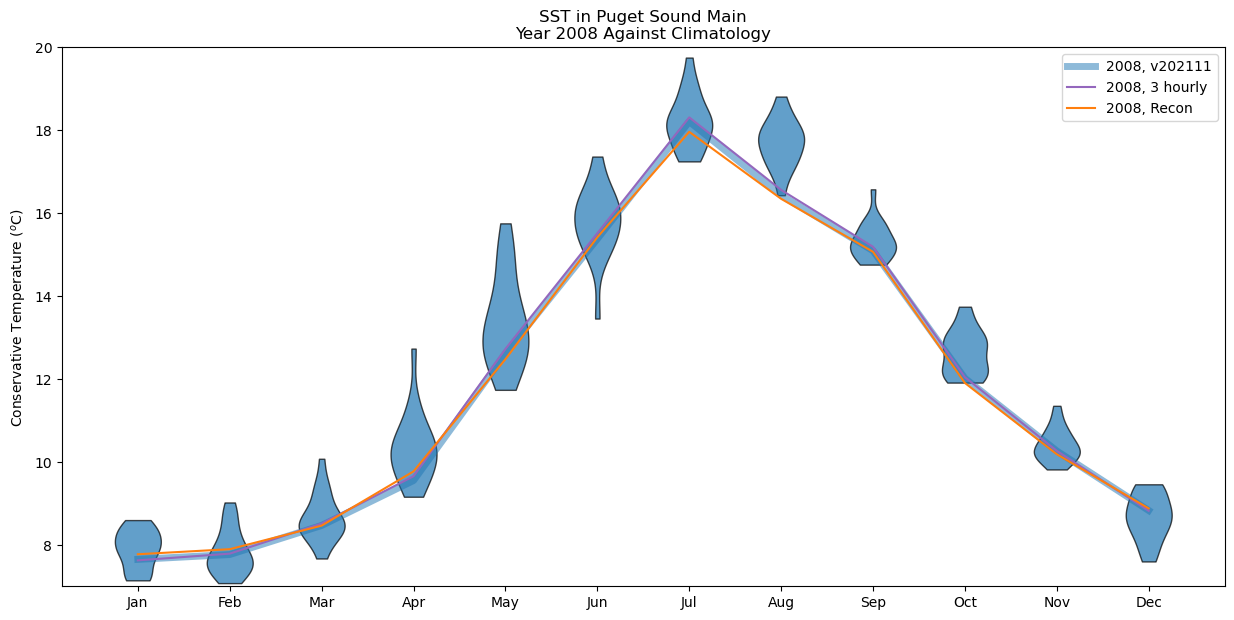

In [304]:
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
parts = ax.violinplot(mean_temp_v, positions=range(1, 13), showmeans=False, showmedians=False, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_edgecolor('black')    # Border color
    pc.set_alpha(0.7)            # Transparency
iy, year = 1, 2008
ax.plot(range(1, 13), mean_temp_v[1], 'tab:blue', alpha=0.5, linewidth=5, label='2008, v202111')
ax.plot(range(1, 13), mean_temp_3h[0], 'tab:purple', label='2008, 3 hourly')
#ax.plot(range(1, 5), mean_temp_pl[0], label='2008, 3 hourly pluck')
#ax.plot(range(1, 5), mean_temp_3h_w1hS[0], label='2008, 3h_w1hS')
ax.plot(range(1, 13), mean_temp_recon[0], 'tab:orange', label='2008, Recon')
#ax.plot(range(1, 5), mean_temp_recon_w1hS[0], label='2008, recon_w1hS')

ax.set_title('SST in Puget Sound Main\nYear 2008 Against Climatology')
ax.set_ylabel('Conservative Temperature ($^o$C)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend();
ax.set_ylim(7, 20);

Temperature is a bit warmer at the surface in Jan/Feb, then cool through Sep, but better here than Central SoG.

### Deep Salinity in the Venus Region ###

In [213]:
# January - June
filestring_template = lambda year, month, last_day: f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_grid_T_{year}{month:02d}01_{year}{month:02d}{last_day:02d}.nc'
mean_salinity_v, mean_salinity_v_time = calculate_timeseries(1, 12+1, filestring_template, mesh, SoG_venus, (32, 32), 'vosaline')
np.savetxt('mean_salinity_v.csv', mean_salinity_v , comments=f'{dt.date.today}')
np.savetxt('mean_salinity_v_time.csv', mean_salinity_v_time , comments=f'{dt.date.today}')

In [211]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_salinity_3h, mean_salinity_3h_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, 
                                                              filestring_template, mesh, SoG_venus, (32, 32), 'vosaline')

In [288]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Pluck/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_salinity_pl, mean_salinity_pl_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, mesh, 
                                                     SoG_venus, (32, 32), 'vosaline')

In [279]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_salinity_3h_w1hS, mean_salinity_3h_w1hs_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                            mesh, SoG_venus, (32, 32), 'vosaline')

In [222]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_salinity_recon, mean_salinity_recon_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, 
                                                                    mesh, SoG_venus, (32, 32), 'vosaline')


In [282]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_grid_T.nc'
mean_salinity_recon_w1hS, mean_salinity_recon_w1hS_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                                  mesh, SoG_venus, (32, 32), 'vosaline')

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(15, 10))
axs[0].plot(mean_salinity_v_time.flatten(), mean_salinity_v.flatten(), label='v202111', marker='+', linestyle='--');
for iy, year in enumerate(range(2007, endyear, 1)):
    axs[0].plot(mean_salinity_v_time[iy], mean_salinity_v.mean(axis=0), label='v202111', linestyle=':', color='grey');
    axs[1].plot(mean_salinity_v_time[iy], mean_salinity_v[iy] - mean_salinity_v.mean(axis=0), label='v202111', marker='+', linestyle='--', color='tab:blue');
for iy, year in enumerate(range(2008, 2008+1, 1)):
    axs[0].plot(mean_salinity_3h_time[iy], mean_salinity_3h[iy], 'ro', label='gemlam every 3h')
    axs[1].plot(mean_salinity_3h_time[iy], mean_salinity_3h[iy] - mean_salinity_v.mean(axis=0) , 'ro', label='gemlam every 3h')
    axs[0].plot(mean_salinity_recon_time[iy], mean_salinity_recon[iy], 'bs', label='recon')
    axs[1].plot(mean_salinity_recon_time[iy], mean_salinity_recon[iy] - mean_salinity_v.mean(axis=0) , 'bs', label='recon')

for ax in axs:
    ax.set_xlabel('Year')
    ax.set_ylabel('Reference Salinity (g kg$^{-1}$)')
#    ax.legend()
    ax.grid();

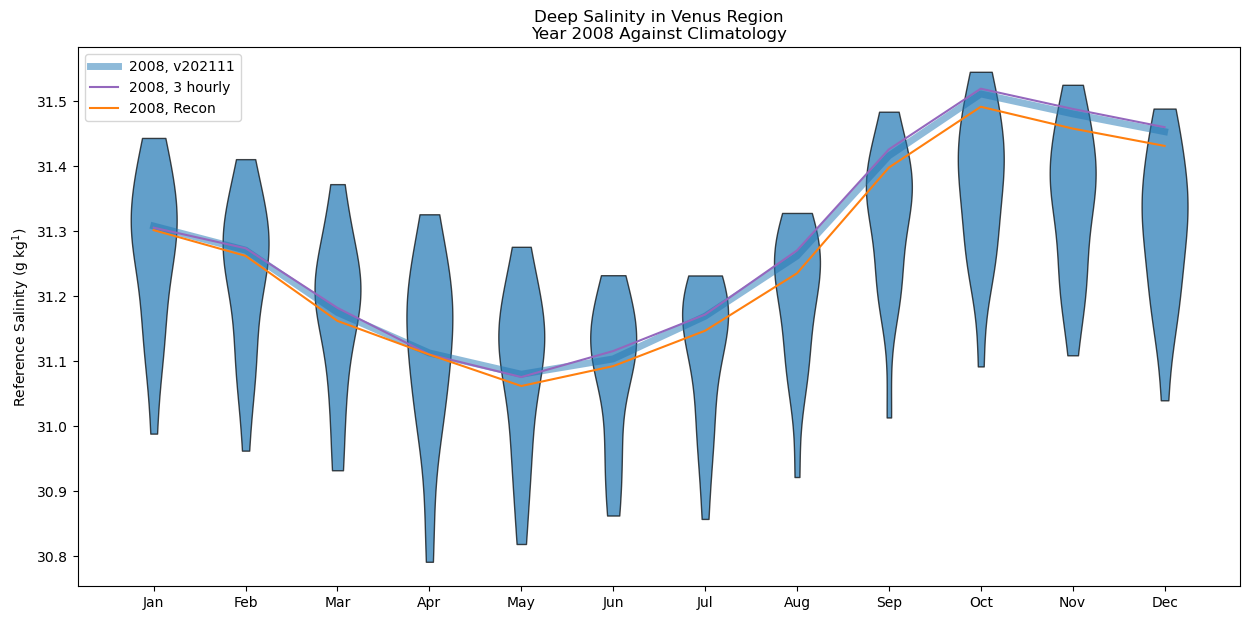

In [305]:
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
parts = ax.violinplot(mean_salinity_v, positions=range(1, 13), showmeans=False, showmedians=False, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_edgecolor('black')    # Border color
    pc.set_alpha(0.7)            # Transparency
iy, year = 1, 2008
ax.plot(range(1, 13), mean_salinity_v[1], 'tab:blue', alpha=0.5, linewidth=5, label='2008, v202111')
ax.plot(range(1, 13), mean_salinity_3h[0], 'tab:purple', label='2008, 3 hourly')
#ax.plot(range(1, 5), mean_salinity_pl[0], label='2008, 3 hourly pluck')
#ax.plot(range(1, 5), mean_salinity_3h_w1hS[0], label='2008, 3h_w1hS')
ax.plot(range(1, 13), mean_salinity_recon[0], 'tab:orange', label='2008, Recon')
#ax.plot(range(1, 5), mean_salinity_recon_w1hS[0], label='2008, recon_w1hS')

ax.set_title('Deep Salinity in Venus Region\nYear 2008 Against Climatology')
ax.set_ylabel('Reference Salinity (g kg$^{1}$)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend();

Salinity is freshening significantly.  Noise???

### Upper Layer Nitrate in the Northern SoG ###

In [225]:
# January - June
filestring_template = lambda year, month, last_day: f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_biol_T_{year}{month:02d}01_{year}{month:02d}{last_day:02d}.nc'
mean_nitrate_v, mean_nitrate_v_time = calculate_timeseries(1, 12+1, filestring_template, mesh, SoG_north, (0, 10), 'nitrate')
np.savetxt('mean_nitrate_v.csv', mean_nitrate_v , comments=f'{dt.date.today}')
np.savetxt('mean_nitrate_v_time.csv', mean_nitrate_v_time , comments=f'{dt.date.today}')

In [226]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_nitrate_3h, mean_nitrate_3h_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, 
                                                            mesh, SoG_north, (0, 10), 'nitrate')


In [256]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Pluck/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_nitrate_pl, mean_nitrate_pl_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                            mesh, SoG_north, (0, 10), 'nitrate')


In [257]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_nitrate_3h_w1hS, mean_nitrate_3h_w1hs_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                            mesh, SoG_north, (0, 10), 'nitrate')


In [229]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_nitrate_recon, mean_nitrate_recon_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, 
                                                                  mesh, SoG_north, (0, 10), 'nitrate')


In [267]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_nitrate_recon_w1hS, mean_nitrate_recon_w1hS_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                                  mesh, SoG_north, (0, 10), 'nitrate')

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(15, 10))
axs[0].plot(mean_nitrate_v_time.flatten(), mean_nitrate_v.flatten(), label='v202111', marker='+', linestyle='--');
for iy, year in enumerate(range(2007, endyear, 1)):
    axs[0].plot(mean_nitrate_v_time[iy], mean_nitrate_v.mean(axis=0), label='v202111', linestyle=':', color='grey');
    axs[1].plot(mean_nitrate_v_time[iy], mean_nitrate_v[iy] - mean_nitrate_v.mean(axis=0), label='v202111', marker='+', linestyle='--', color='tab:blue');
for iy, year in enumerate(range(2008, 2008+1, 1)):
    axs[0].plot(mean_nitrate_3h_time[iy], mean_nitrate_3h[iy], 'ro', label='gemlam every 3h')
    axs[1].plot(mean_nitrate_3h_time[iy], mean_nitrate_3h[iy] - mean_nitrate_v.mean(axis=0) , 'ro', label='gemlam every 3h')
    axs[0].plot(mean_nitrate_recon_time[iy], mean_nitrate_recon[iy], 'bs', label='recon')
    axs[1].plot(mean_nitrate_recon_time[iy], mean_nitrate_recon[iy] - mean_nitrate_v.mean(axis=0) , 'bs', label='recon')

for ax in axs:
    ax.set_xlabel('Year')
    ax.set_ylabel('Nitrate (mmol m$^{-3}$)')
#    ax.legend()
    ax.grid();

fig.suptitle('SoG North, 0-10 m Nitrate');

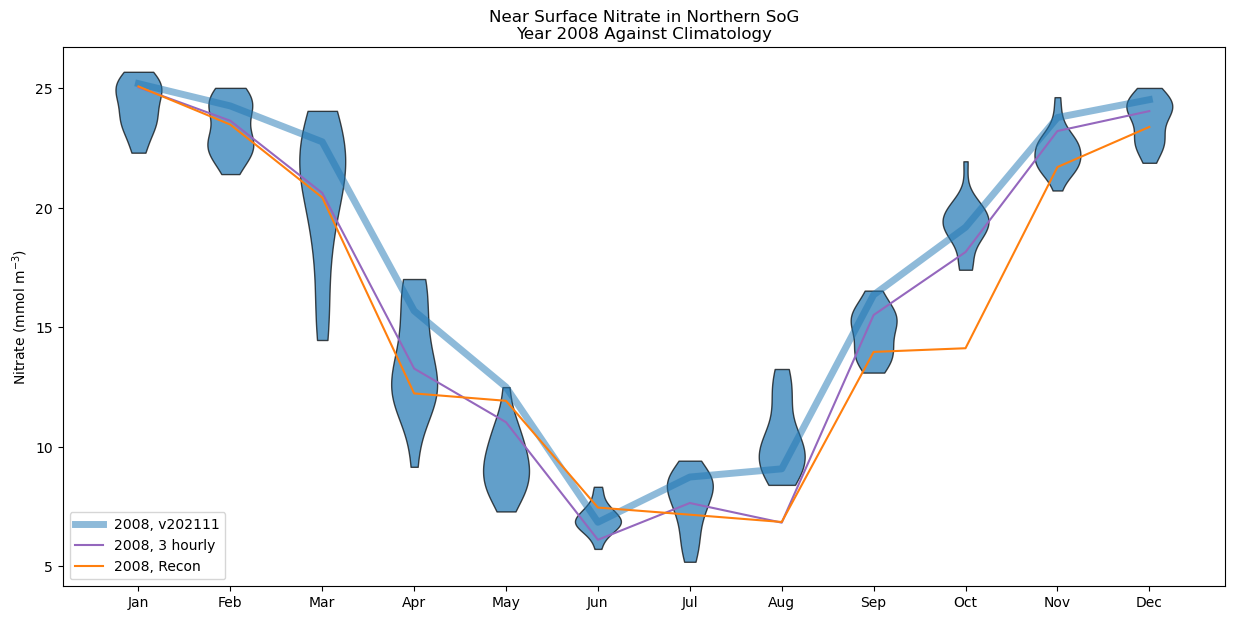

In [306]:
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
parts = ax.violinplot(mean_nitrate_v, positions=range(1, 13), showmeans=False, showmedians=False, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_edgecolor('black')    # Border color
    pc.set_alpha(0.7)            # Transparency
iy, year = 1, 2008
ax.plot(range(1, 13), mean_nitrate_v[1], 'tab:blue', alpha=0.5, linewidth=5, label='2008, v202111')
ax.plot(range(1, 13), mean_nitrate_3h[0], 'tab:purple', label='2008, 3 hourly')
#ax.plot(range(1, 5), mean_nitrate_pl[0], label='2008, 3h pluck')
#ax.plot(range(1, 5), mean_nitrate_3h_w1hS[0], label='2008, 3h_w1hS')
ax.plot(range(1, 13), mean_nitrate_recon[0], 'tab:orange', label='2008, Recon')
#ax.plot(range(1, 5), mean_nitrate_recon_w1hS[0], label='2008, Recon_w1hS')
ax.set_title('Near Surface Nitrate in Northern SoG\nYear 2008 Against Climatology')
ax.set_ylabel('Nitrate (mmol m$^{-3}$)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend();

Pretty terrible.  The Recon and 3 hr match well through May, okay Jul and Aug and then deviate in the Fall.  But both are very different that v202111.

### Diatoms in the NSoG ###

In [232]:
# January - April
filestring_template = lambda year, month, last_day: f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_biol_T_{year}{month:02d}01_{year}{month:02d}{last_day:02d}.nc'
mean_diatoms_v, mean_diatoms_v_time = calculate_timeseries(1, 12+1, filestring_template, mesh, SoG_north, (0, 10), 'diatoms')
np.savetxt('mean_diatoms_v.csv', mean_diatoms_v , comments=f'{dt.date.today}')
np.savetxt('mean_diatoms_v_time.csv', mean_diatoms_v_time , comments=f'{dt.date.today}')

In [233]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_diatoms_3h, mean_diatoms_3h_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, 
                                                            mesh, SoG_north, (0, 10), 'diatoms')


In [260]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Pluck/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_diatoms_pl, mean_diatoms_pl_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                            mesh, SoG_north, (0, 10), 'diatoms')


In [261]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_diatoms_3h_w1hS, mean_diatoms_3h_w1hs_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                            mesh, SoG_north, (0, 10), 'diatoms')

In [234]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_diatoms_recon, mean_diatoms_recon_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, 
                                                                  mesh, SoG_north, (0, 10), 'diatoms')


In [269]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_diatoms_recon_w1hS, mean_diatoms_recon_w1hS_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                                  mesh, SoG_north, (0, 10), 'diatoms')

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(15, 10))
axs[0].plot(mean_diatoms_v_time.flatten(), mean_diatoms_v.flatten(), label='v202111', marker='+', linestyle='--');
for iy, year in enumerate(range(2007, endyear, 1)):
    axs[0].plot(mean_diatoms_v_time[iy], mean_diatoms_v.mean(axis=0), label='v202111', linestyle=':', color='grey');
    axs[1].plot(mean_diatoms_v_time[iy], mean_diatoms_v[iy] - mean_diatoms_v.mean(axis=0), label='v202111', marker='+', linestyle='--', color='tab:blue');
for iy, year in enumerate(range(2008, 2008+1, 1)):
    axs[0].plot(mean_diatoms_3h_time[iy], mean_diatoms_3h[iy], 'ro', label='gemlam every 3h')
    axs[1].plot(mean_diatoms_3h_time[iy], mean_diatoms_3h[iy] - mean_diatoms_v.mean(axis=0) , 'ro', label='gemlam every 3h')
    axs[0].plot(mean_diatoms_recon_time[iy], mean_diatoms_recon[iy], 'bs', label='recon')
    axs[1].plot(mean_diatoms_recon_time[iy], mean_diatoms_recon[iy] - mean_diatoms_v.mean(axis=0) , 'bs', label='recon')
for ax in axs:
    ax.set_xlabel('Year')
    ax.set_ylabel('Diatoms (mmol m$^{-3}$)')
#    ax.legend()
    ax.grid();

fig.suptitle('SoG North, 0-10 m Diatoms');



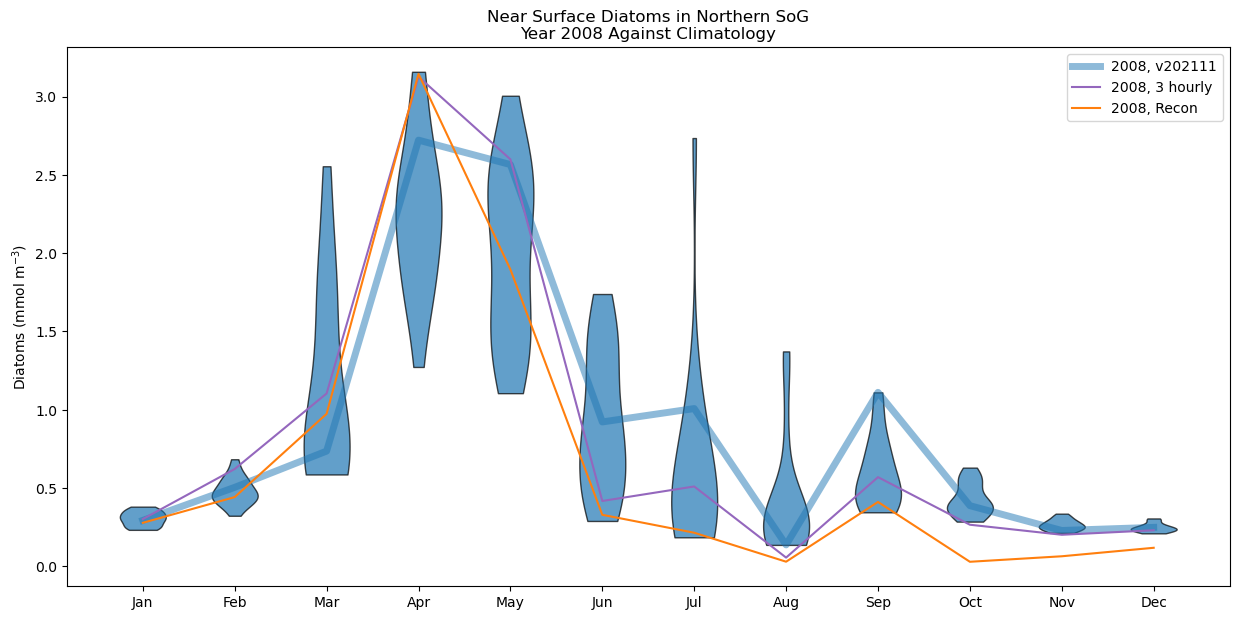

In [307]:
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
parts = ax.violinplot(mean_diatoms_v, positions=range(1, 13), showmeans=False, showmedians=False, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_edgecolor('black')    # Border color
    pc.set_alpha(0.7)            # Transparency
iy, year = 1, 2008
ax.plot(range(1, 13), mean_diatoms_v[1], 'tab:blue', alpha=0.5, linewidth=5, label='2008, v202111')
ax.plot(range(1, 13), mean_diatoms_3h[0], 'tab:purple', label='2008, 3 hourly')
#ax.plot(range(1, 5), mean_diatoms_pl[0], label='2008, 3h pluck')
#ax.plot(range(1, 5), mean_diatoms_3h_w1hS[0], label='2008, 3h_w1hS')
ax.plot(range(1, 13), mean_diatoms_recon[0], 'tab:orange', label='2008, Recon')
#ax.plot(range(1, 5), mean_diatoms_recon_w1hS[0], label='2008, Recon_w1hS')
ax.set_title('Near Surface Diatoms in Northern SoG\nYear 2008 Against Climatology')
ax.set_ylabel('Diatoms (mmol m$^{-3}$)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend();

Egads!

### Nanoflagellates in the north Central SoG ###

Based on the problems with Central SoG for temperature, I'm going to use a smaller Central Box.

In [238]:
# January - June
filestring_template = lambda year, month, last_day: f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_biol_T_{year}{month:02d}01_{year}{month:02d}{last_day:02d}.nc'
mean_flag_v, mean_flag_v_time = calculate_timeseries(1, 12+1, filestring_template, mesh, SoG_ncenter, (0, 10), 'flagellates')
np.savetxt('mean_flag_v.csv', mean_flag_v , comments=f'{dt.date.today}')
np.savetxt('mean_flag_v_time.csv', mean_flag_v_time , comments=f'{dt.date.today}')

In [240]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_flag_3h, mean_flag_3h_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, 
                                                      mesh, SoG_ncenter, (0, 10), 'flagellates')


In [263]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Pluck/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_flag_pl, mean_flag_pl_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                      mesh, SoG_ncenter, (0, 10), 'flagellates')

In [264]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_flag_3h_w1hS, mean_flag_3h_w1hs_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                            mesh, SoG_ncenter, (0, 10), 'flagellates')

In [241]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_flag_recon, mean_flag_recon_time = calculate_ts_newrun(1, 12+1, 2008, 2008+1, filestring_template, 
                                                            mesh, SoG_ncenter, (0, 10), 'flagellates')


In [271]:
filestring_template = lambda year, month: f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/monthlies_w1hS/SalishSea_1m_{year}{month:02d}_{year}{month:02d}_biol_T.nc'
mean_flag_recon_w1hS, mean_flag_recon_w1hS_time = calculate_ts_newrun(1, 4+1, 2008, 2008+1, filestring_template, 
                                                                  mesh, SoG_ncenter, (0, 10), 'flagellates')

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(15, 10))
axs[0].plot(mean_flag_v_time.flatten(), mean_flag_v.flatten(), label='v202111', marker='+', linestyle='--');
for iy, year in enumerate(range(2007, endyear, 1)):
    axs[0].plot(mean_flag_v_time[iy], mean_flag_v.mean(axis=0), label='v202111', linestyle=':', color='grey');
    axs[1].plot(mean_flag_v_time[iy], mean_flag_v[iy] - mean_flag_v.mean(axis=0), label='v202111', marker='+', linestyle='--', color='tab:blue');
for iy, year in enumerate(range(2008, 2008+1, 1)):
    axs[0].plot(mean_flag_3h_time[iy], mean_flag_3h[iy], 'ro', label='gemlam every 3h')
    axs[1].plot(mean_flag_3h_time[iy], mean_flag_3h[iy] - mean_flag_v.mean(axis=0) , 'ro', label='gemlam every 3h')
    axs[0].plot(mean_flag_recon_time[iy], mean_flag_recon[iy], 'bs', label='recon')
    axs[1].plot(mean_flag_recon_time[iy], mean_flag_recon[iy] - mean_flag_v.mean(axis=0) , 'bs', label='recon')
for ax in axs:
    ax.set_xlabel('Year')
    ax.set_ylabel('Nanoflagellates (mmol m$^{-3}$)')
#    ax.legend()
    ax.grid();

fig.suptitle('SoG north Central, 0-10 m Nanoflagellates');

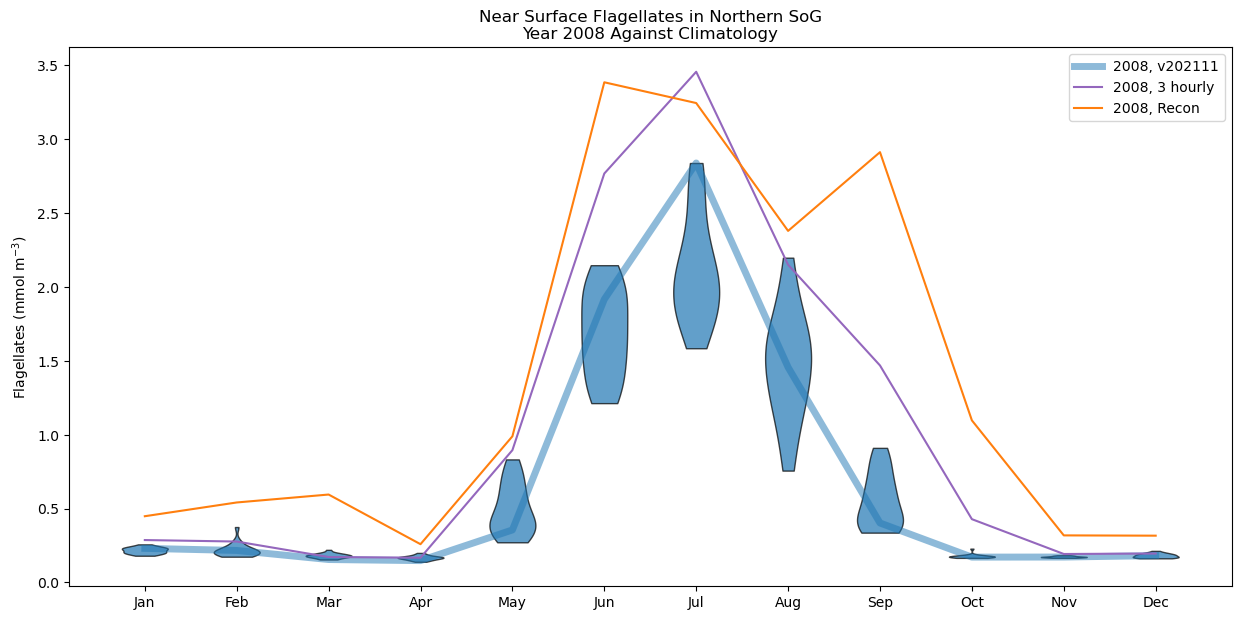

In [308]:
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
parts = ax.violinplot(mean_flag_v, positions=range(1, 13), showmeans=False, showmedians=False, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_edgecolor('black')    # Border color
    pc.set_alpha(0.7)            # Transparency
iy, year = 1, 2008
ax.plot(range(1, 13), mean_flag_v[1], 'tab:blue', alpha=0.5, linewidth=5, label='2008, v202111')
ax.plot(range(1, 13), mean_flag_3h[0], 'tab:purple', label='2008, 3 hourly')
#ax.plot(range(1, 5), mean_flag_pl[0], label='2008, 3 hourly plucked')
#ax.plot(range(1, 5), mean_flag_3h_w1hS[0], label='2008, 3h w1hS')
ax.plot(range(1, 13), mean_flag_recon[0], 'tab:orange', label='2008, Recon')
#ax.plot(range(1, 5), mean_flag_recon_w1hS[0], label='2008, Recon_w1hS')
ax.set_title('Near Surface Flagellates in Northern SoG\nYear 2008 Against Climatology')
ax.set_ylabel('Flagellates (mmol m$^{-3}$)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend();
#ax.set_ylim(0, 0.5);

Egads, Nanoflagellate bloom in 3 hourly case (did I average or pluck?)  
I averaged.  What if I pluck?

## Use Original, Hourly Solar ##

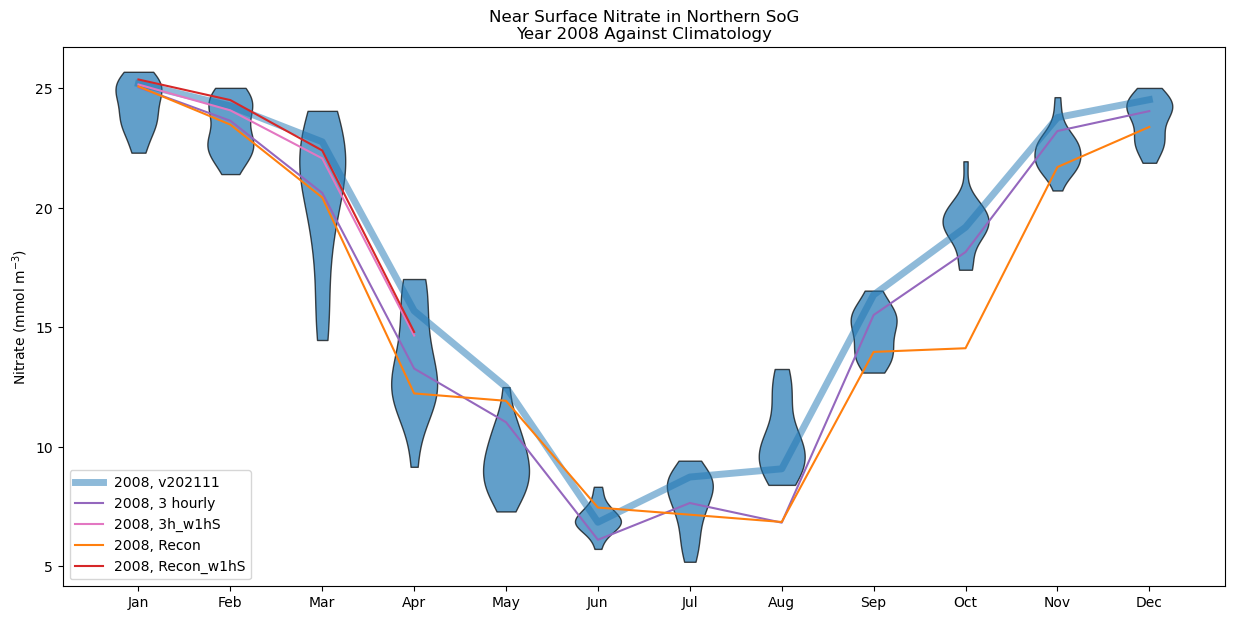

In [312]:
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
parts = ax.violinplot(mean_nitrate_v, positions=range(1, 13), showmeans=False, showmedians=False, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_edgecolor('black')    # Border color
    pc.set_alpha(0.7)            # Transparency
iy, year = 1, 2008
ax.plot(range(1, 13), mean_nitrate_v[1], 'tab:blue', alpha=0.5, linewidth=5, label='2008, v202111')
ax.plot(range(1, 13), mean_nitrate_3h[0], 'tab:purple', label='2008, 3 hourly')
#ax.plot(range(1, 5), mean_nitrate_pl[0], label='2008, 3h pluck')
ax.plot(range(1, 5), mean_nitrate_3h_w1hS[0], 'tab:pink', label='2008, 3h_w1hS')
ax.plot(range(1, 13), mean_nitrate_recon[0], 'tab:orange', label='2008, Recon')
ax.plot(range(1, 5), mean_nitrate_recon_w1hS[0], 'tab:red', label='2008, Recon_w1hS')
ax.set_title('Near Surface Nitrate in Northern SoG\nYear 2008 Against Climatology')
ax.set_ylabel('Nitrate (mmol m$^{-3}$)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend();

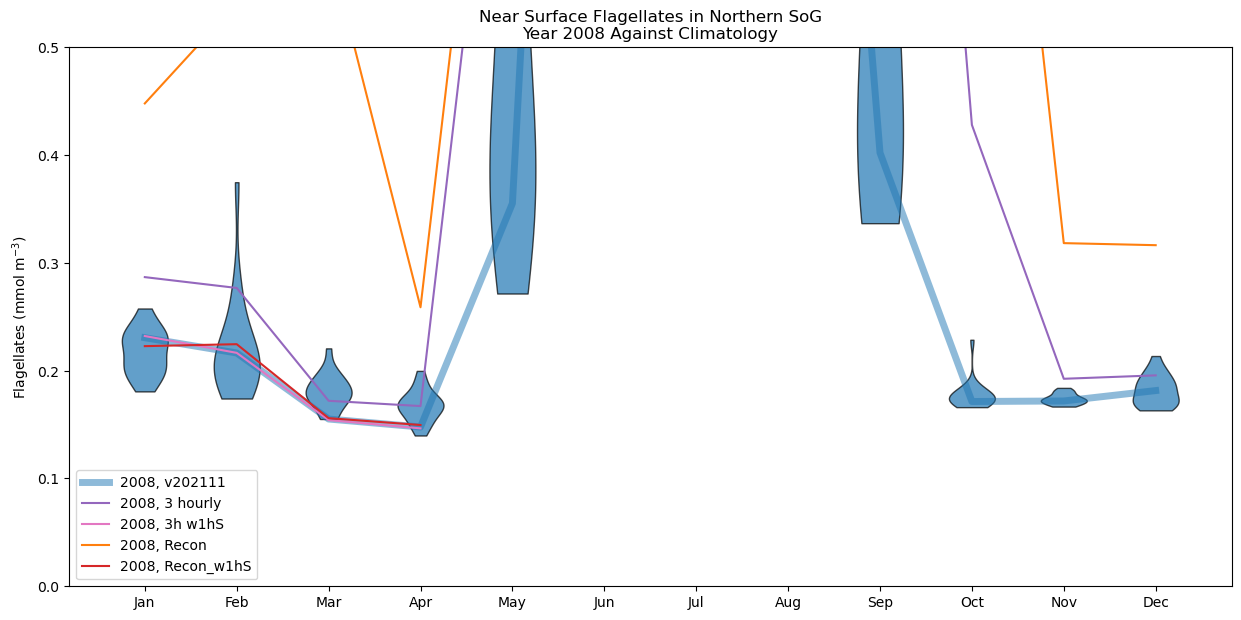

In [314]:
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
parts = ax.violinplot(mean_flag_v, positions=range(1, 13), showmeans=False, showmedians=False, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_edgecolor('black')    # Border color
    pc.set_alpha(0.7)            # Transparency
iy, year = 1, 2008
ax.plot(range(1, 13), mean_flag_v[1], 'tab:blue', alpha=0.5, linewidth=5, label='2008, v202111')
ax.plot(range(1, 13), mean_flag_3h[0], 'tab:purple', label='2008, 3 hourly')
#ax.plot(range(1, 5), mean_flag_pl[0], label='2008, 3 hourly plucked')
ax.plot(range(1, 5), mean_flag_3h_w1hS[0], 'tab:pink', label='2008, 3h w1hS')
ax.plot(range(1, 13), mean_flag_recon[0], 'tab:orange', label='2008, Recon')
ax.plot(range(1, 5), mean_flag_recon_w1hS[0], 'tab:red', label='2008, Recon_w1hS')
ax.set_title('Near Surface Flagellates in Northern SoG\nYear 2008 Against Climatology')
ax.set_ylabel('Flagellates (mmol m$^{-3}$)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend();
ax.set_ylim(0, 0.5);